# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [1]:
import polars as pl
import uproot
import awkward as ak

from fastfeedback import DataManager

data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")
df = data_manager.prepare_data()
caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]
Enu_e_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_mu_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
data = caf_tree.arrays([Enu_e_had, Enu_mu_had, Enu_mu_range])

df2: pl.DataFrame = pl.from_pandas(ak.to_dataframe(data, how="outer"))
df2.columns = ["Enu_e_had", "Enu_mu_had", "Enu_mu_range"]

reco_pfp_tree = uproot.open("example-cafs-root/reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df: pl.DataFrame = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

electron_mask = pl.col("nuPDG").abs() == 12
muon_mask = pl.col("nuPDG").abs() == 14

electron_inelasticity = 1 - (pl.col("Enu_e_had") / pl.col("recoE_nue"))
muon_inelasticity = 1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))

nu_mask = pl.col("nuPDG") > 0
nubar_mask = pl.col("nuPDG") < 0

data: pl.DataFrame = (
    pl.concat([df, df2, reco_pfp_df], how="horizontal")
    .filter(pl.col("reco_ok") == True)
    .filter(pl.col("direc_reco") != 0)
    .with_columns(
        pl.when(electron_mask)
        .then(electron_inelasticity)
        .when(muon_mask)
        .then(muon_inelasticity)
        .otherwise(None)
        .alias("inelasticity")
    )
    .drop("reco_ok", "direc_numu", "direc_nue", "direc_nc", "recoE_numu", "recoE_nue")
    .drop_nulls()
)

data

Loading data...


/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


run,weight,flux_nue,flux_numu,xsec,nue_w,numu_w,osc_from_e_w,osc_from_mu_w,final_oscillated_w,genie_weight,nuPDG,Ev,isCC,NuMomY,mode,cvn_numu,cvn_nue,cvn_nc,npfps,direc_true,reco_pdg,recoE,direc_reco,Enu_e_had,Enu_mu_had,Enu_mu_range,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f32,bool,f32,i32,f64,f64,f64,f64,f32,i32,f64,f64,f32,f32,f32,i32,i32,i32,f32,i32,i32,f64
0,2.4045136e7,0.002161,0.007993,3.63535,0.007857,0.029058,0.999988,0.000005,0.007857,2.4045136e7,-12,35.698929,true,5.325916,1,0.001684,0.994011,0.004305,9.0,-0.14919,12,28.432413,-0.291152,12.376396,28.015844,28.529816,10,5,4,11.48799,4,1,0.564708
0,6.0056676e7,700.832829,1458.73821,0.000058,0.040934,0.085202,0.815649,0.004269,0.033752,6.0056676e7,-12,0.425595,true,-0.055933,0,0.001051,0.986669,0.01228,1.0,0.131423,12,0.208079,0.092648,0.09995,0.09995,0.322256,2,1,0,0.11094,1,0,0.519653
0,5.3239364e7,15.426308,37.089519,0.001919,0.0296,0.071168,0.009378,0.936898,0.066955,5.3239364e7,-14,1.668767,true,-0.83822,1,0.982827,0.00081,0.016363,3.0,0.502299,14,1.20171,0.167917,0.306345,0.306345,1.20171,4,3,0,0.06457,2,1,0.745076
0,4.2416768e7,0.484793,1.349071,0.03979,0.01929,0.05368,0.999906,0.000037,0.01929,4.2416768e7,-12,5.871087,true,1.988128,1,0.889773,0.000665,0.109562,1.0,-0.33863,14,0.309697,0.373755,0.0,0.0,0.1223,2,1,0,0.003319,1,0,1.0
0,3.3725248e7,0.103483,0.371496,0.107673,0.011142,0.04,0.008681,0.294288,0.011868,3.3725248e7,-14,8.767002,false,-4.042854,2,0.224252,0.047756,0.727992,9.0,0.461144,0,1.18506,0.784457,0.05674,0.05674,0.508249,2,1,0,0.010483,0,1,0.888362
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,3.3414486e7,0.064264,0.176059,0.272591,0.017518,0.047992,0.000014,0.999613,0.047974,3.3414486e7,14,12.654237,true,3.211544,0,0.968268,0.003848,0.027884,3.0,-0.253792,14,3.704717,0.113819,0.212121,4.230925,4.359765,7,4,1,0.274192,3,1,0.029552
0,4.7914404e7,50.127813,115.380758,0.000596,0.029898,0.068818,0.054774,0.210969,0.016156,4.7914404e7,14,1.042722,false,-0.966394,0,0.527526,0.001337,0.471137,1.0,0.926799,14,2.243878,0.899609,0.15033,0.15033,0.389632,2,0,1,0.037859,0,0,0.614174
0,2.5720664e7,1042.373838,2071.887123,0.000018,0.018585,0.036942,0.001904,0.945746,0.034973,2.5720664e7,14,0.31196,true,0.274496,0,0.99478,0.001054,0.004166,1.0,-0.879909,14,0.260973,-0.396677,0.0,0.0,0.011892,3,1,1,0.018882,0,1,1.0


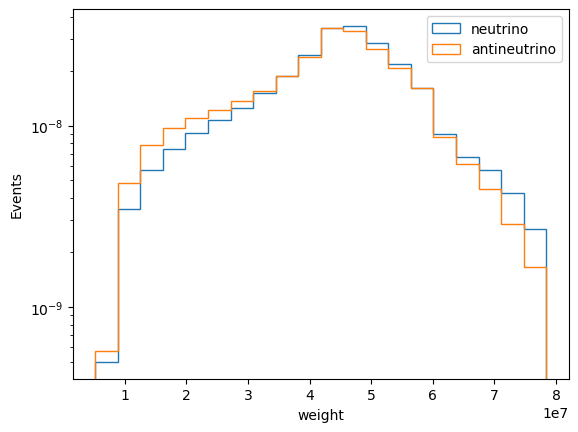

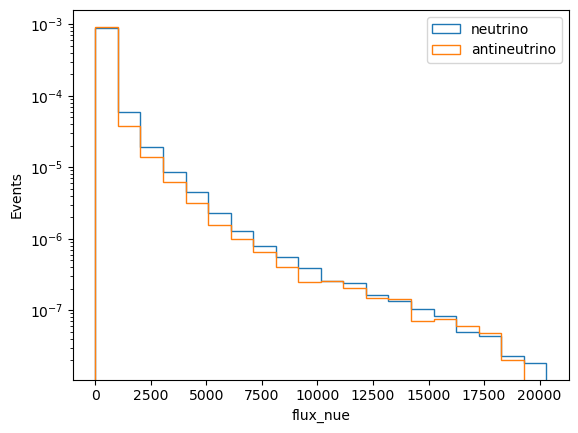

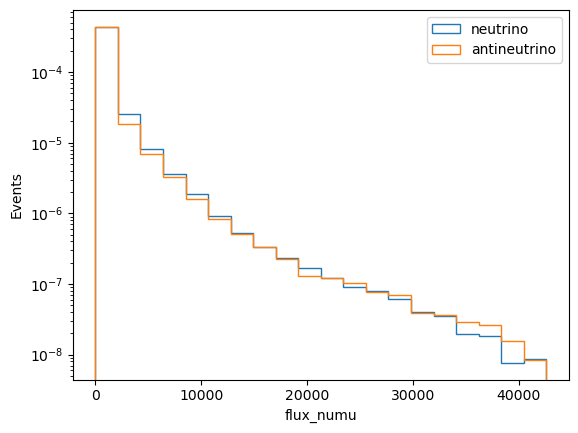

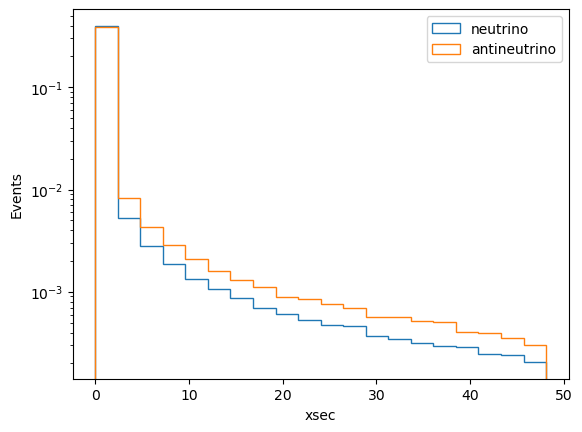

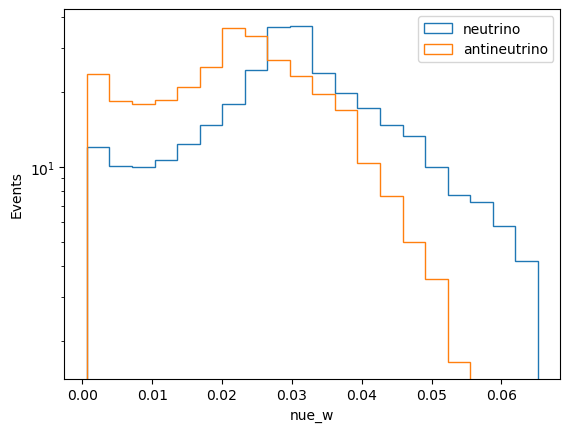

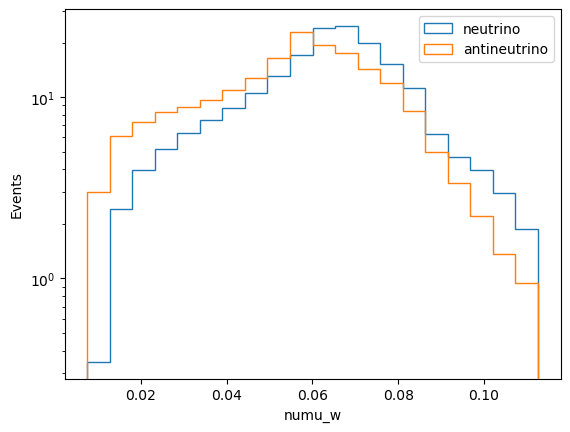

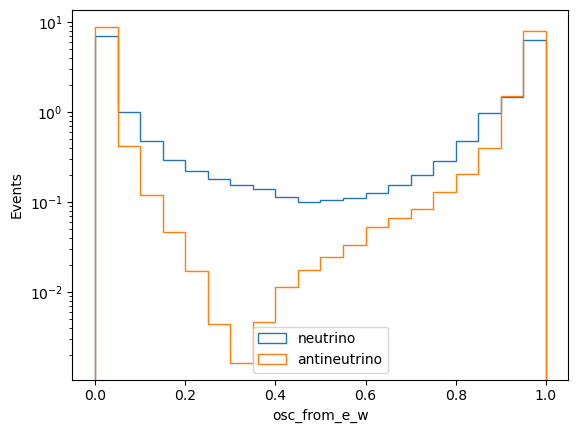

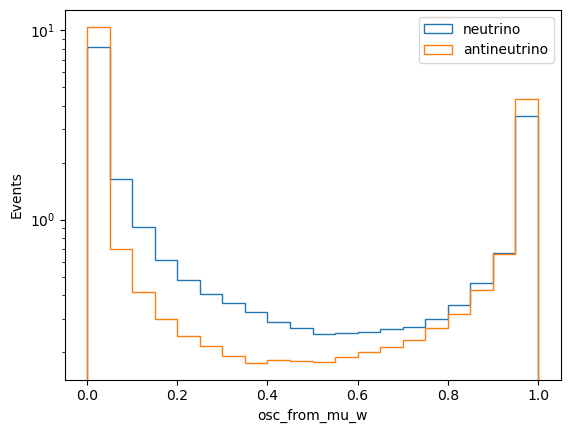

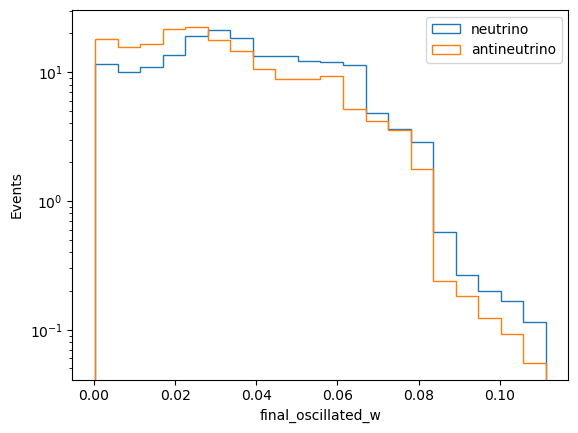

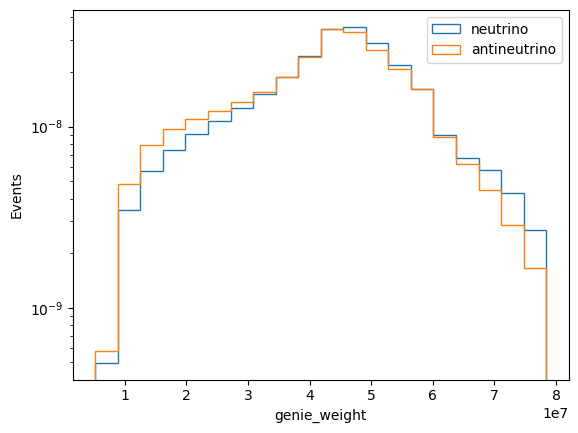

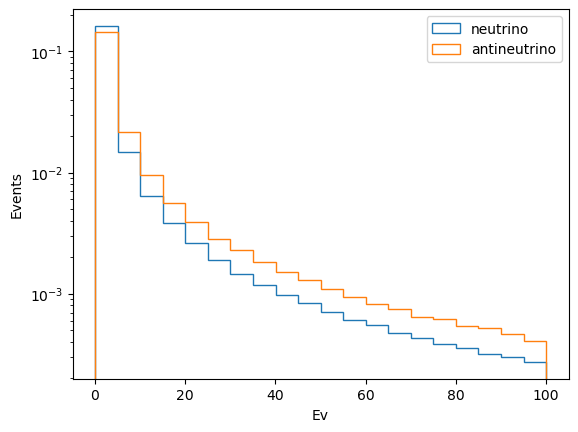

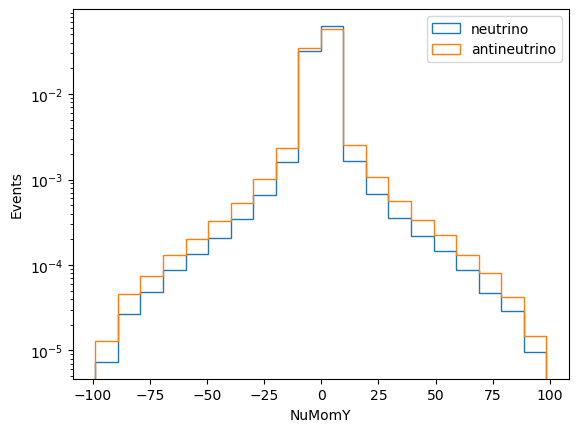

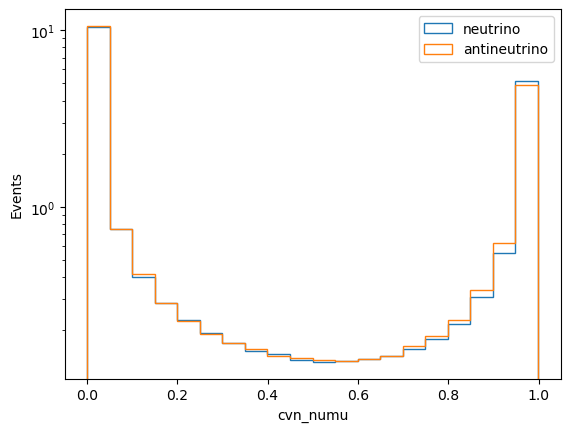

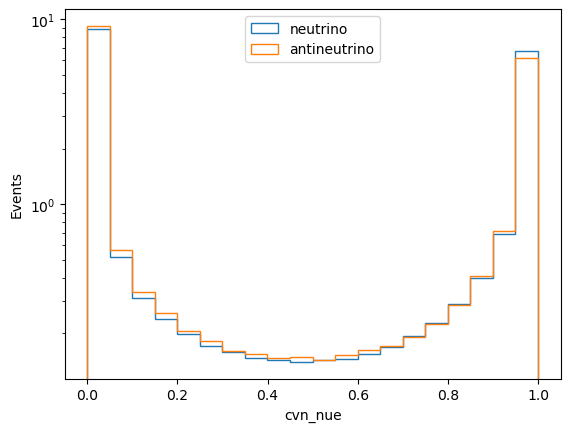

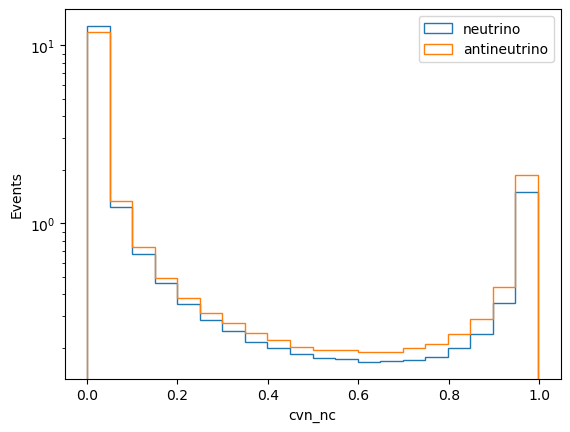

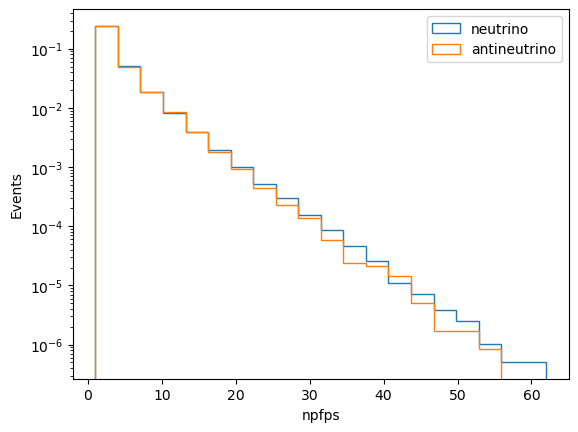

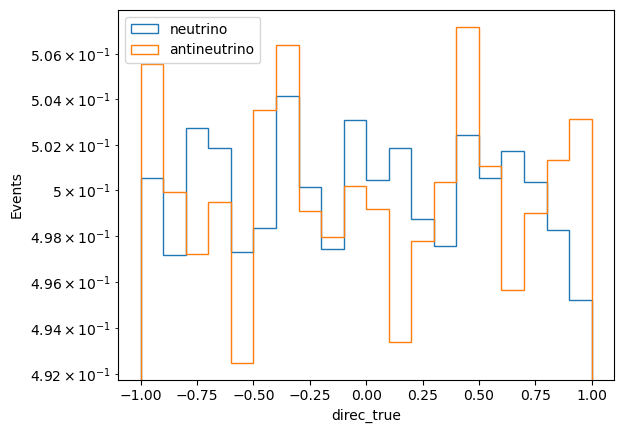

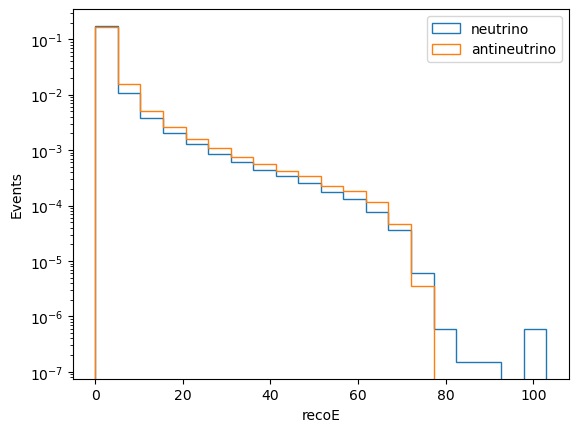

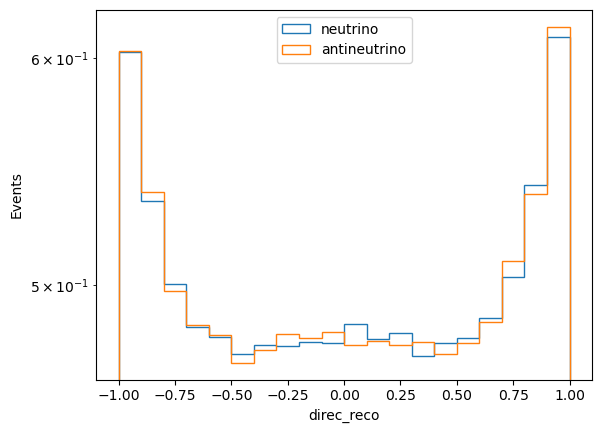

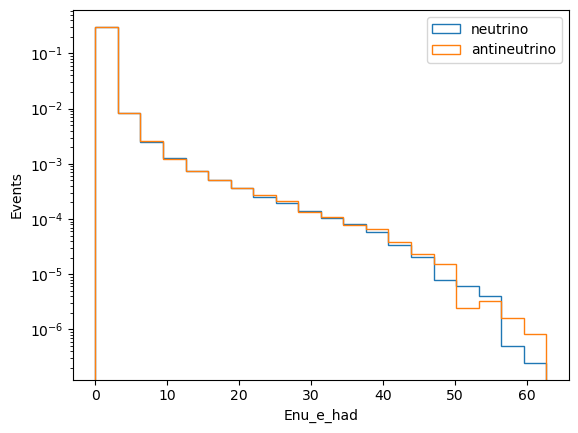

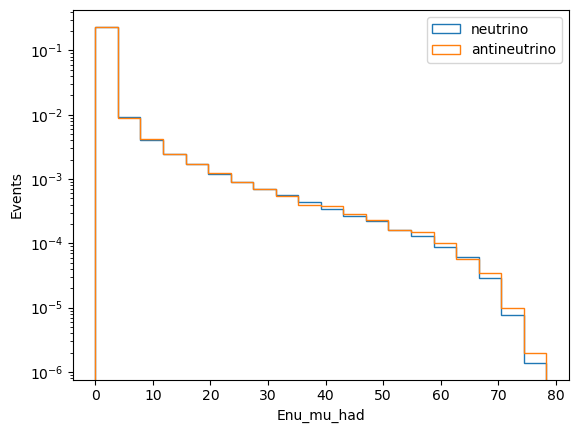

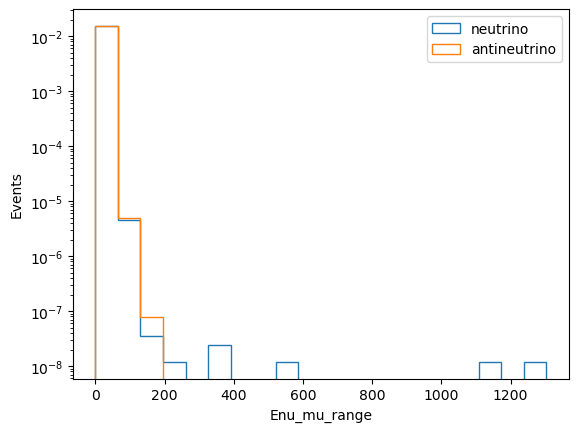

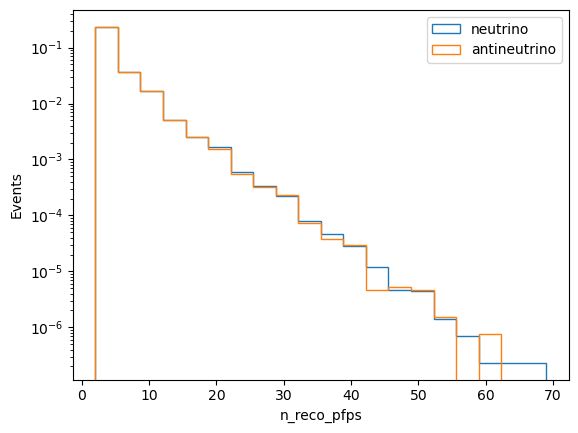

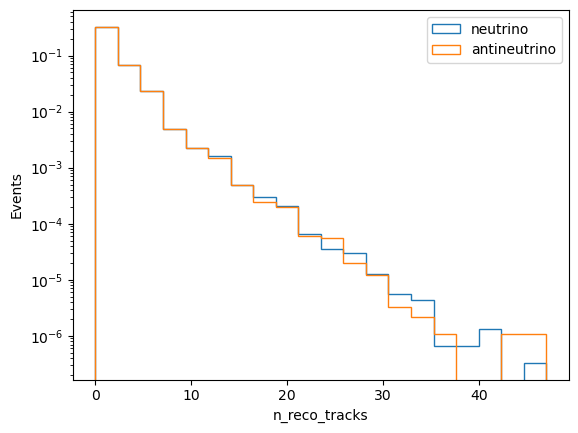

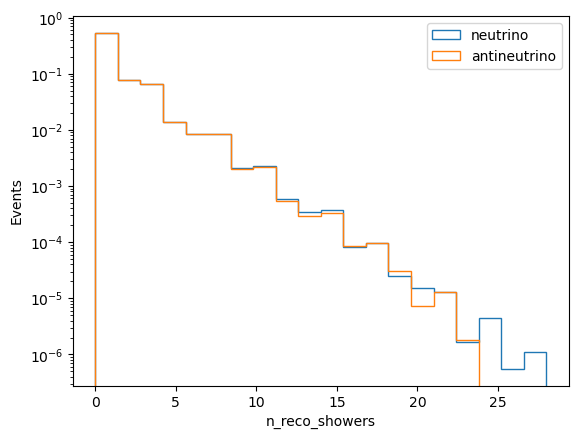

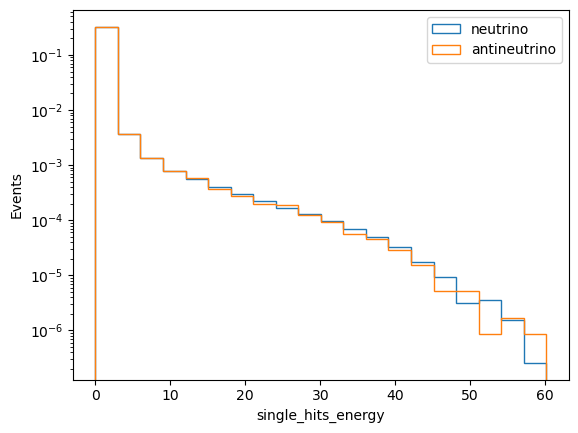

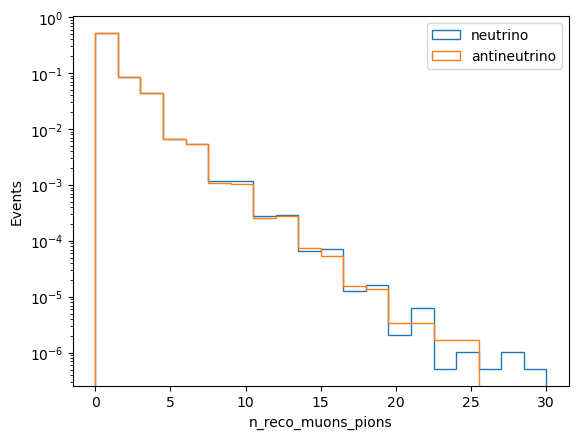

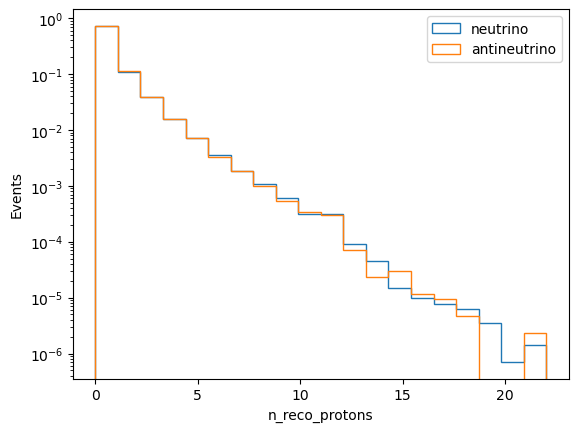

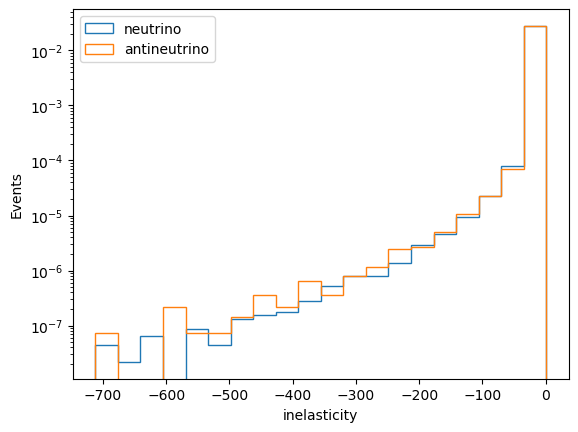

In [2]:
import matplotlib.pyplot as plt

for col in data.columns:
    if col in ["run", "nuPDG", "isCC", "mode", "reco_pdg"]:
        continue

    _, bins, _ = plt.hist(
        data.filter(nu_mask)[col],
        label="neutrino",
        histtype="step",
        bins=20,
        density=True,
    )
    plt.hist(
        data.filter(nubar_mask)[col],
        label="antineutrino",
        histtype="step",
        bins=bins,
        density=True,
    )
    plt.legend()
    plt.yscale("log")
    plt.xlabel(col)
    plt.ylabel("Events")
    plt.show()

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

# get your input data into an array which is N_events x N_variables
X_data = data.drop("nuPDG", "nue_w", "numu_w", "final_oscillated_w")

# create an array of truth labels (one per event) - 0 for neutrino, 1 for anti-neutrino
y_data = (data["nuPDG"] < 0).to_numpy().astype(int)
y_data_uniques = np.unique(y_data)
print(y_data_uniques)

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, random_state=0)
X_data

[0 1]


run,weight,flux_nue,flux_numu,xsec,osc_from_e_w,osc_from_mu_w,genie_weight,Ev,isCC,NuMomY,mode,cvn_numu,cvn_nue,cvn_nc,npfps,direc_true,reco_pdg,recoE,direc_reco,Enu_e_had,Enu_mu_had,Enu_mu_range,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity
i32,f64,f64,f64,f64,f64,f64,f64,f32,bool,f32,i32,f64,f64,f64,f64,f32,i32,f64,f64,f32,f32,f32,i32,i32,i32,f32,i32,i32,f64
0,2.4045136e7,0.002161,0.007993,3.63535,0.999988,0.000005,2.4045136e7,35.698929,true,5.325916,1,0.001684,0.994011,0.004305,9.0,-0.14919,12,28.432413,-0.291152,12.376396,28.015844,28.529816,10,5,4,11.48799,4,1,0.564708
0,6.0056676e7,700.832829,1458.73821,0.000058,0.815649,0.004269,6.0056676e7,0.425595,true,-0.055933,0,0.001051,0.986669,0.01228,1.0,0.131423,12,0.208079,0.092648,0.09995,0.09995,0.322256,2,1,0,0.11094,1,0,0.519653
0,5.3239364e7,15.426308,37.089519,0.001919,0.009378,0.936898,5.3239364e7,1.668767,true,-0.83822,1,0.982827,0.00081,0.016363,3.0,0.502299,14,1.20171,0.167917,0.306345,0.306345,1.20171,4,3,0,0.06457,2,1,0.745076
0,4.2416768e7,0.484793,1.349071,0.03979,0.999906,0.000037,4.2416768e7,5.871087,true,1.988128,1,0.889773,0.000665,0.109562,1.0,-0.33863,14,0.309697,0.373755,0.0,0.0,0.1223,2,1,0,0.003319,1,0,1.0
0,3.3725248e7,0.103483,0.371496,0.107673,0.008681,0.294288,3.3725248e7,8.767002,false,-4.042854,2,0.224252,0.047756,0.727992,9.0,0.461144,0,1.18506,0.784457,0.05674,0.05674,0.508249,2,1,0,0.010483,0,1,0.888362
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,3.3414486e7,0.064264,0.176059,0.272591,0.000014,0.999613,3.3414486e7,12.654237,true,3.211544,0,0.968268,0.003848,0.027884,3.0,-0.253792,14,3.704717,0.113819,0.212121,4.230925,4.359765,7,4,1,0.274192,3,1,0.029552
0,4.7914404e7,50.127813,115.380758,0.000596,0.054774,0.210969,4.7914404e7,1.042722,false,-0.966394,0,0.527526,0.001337,0.471137,1.0,0.926799,14,2.243878,0.899609,0.15033,0.15033,0.389632,2,0,1,0.037859,0,0,0.614174
0,2.5720664e7,1042.373838,2071.887123,0.000018,0.001904,0.945746,2.5720664e7,0.31196,true,0.274496,0,0.99478,0.001054,0.004166,1.0,-0.879909,14,0.260973,-0.396677,0.0,0.0,0.011892,3,1,1,0.018882,0,1,1.0


Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier

clf = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [5]:
# this will be a value between 0 and 1 for each event, indicating "probability" that the event is anti-neutrino

# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

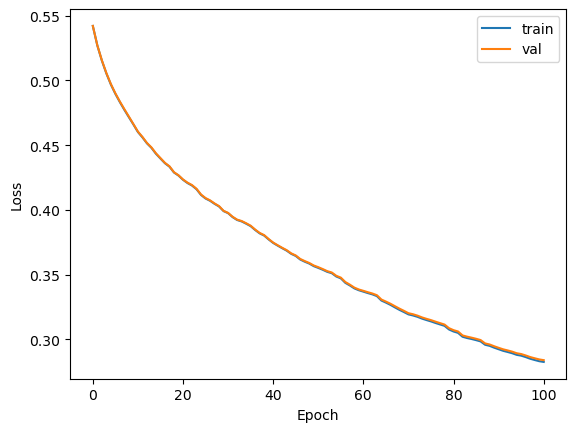

In [6]:
train_loss = -clf.train_score_
val_loss = -clf.validation_score_

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

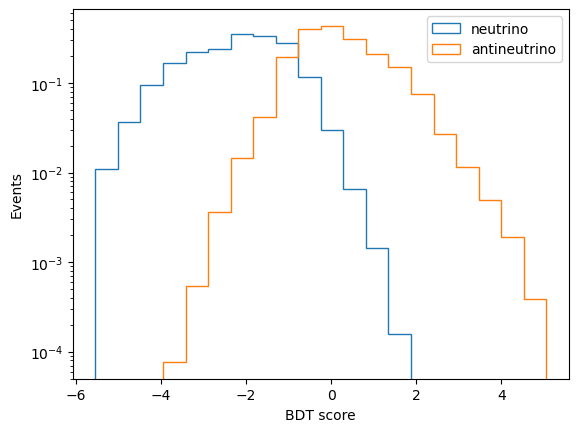

1.8851224861563423


In [7]:
nu_index = 0
nubar_index = 1

n, bins, _ = plt.hist(
    scores_test[y_test == nu_index],
    label="neutrino",
    histtype="step",
    bins=20,
    range=(scores_test.min(), scores_test.max()),
    density=True,
)
plt.hist(
    scores_test[y_test == nubar_index],
    label="antineutrino",
    histtype="step",
    bins=bins,
    density=True,
)
plt.legend()
plt.yscale("log")
plt.xlabel("BDT score")
plt.ylabel("Events")
plt.show()

print(np.sum(n))

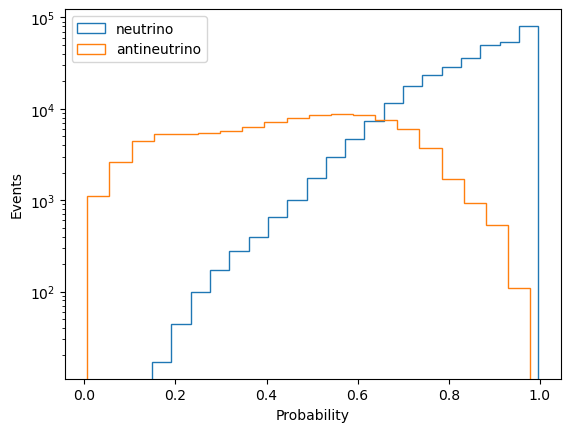

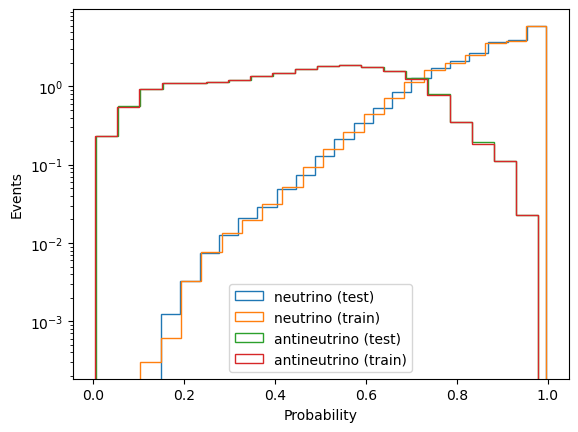

In [8]:
prob_test_nu = 1 / (1 + np.exp(scores_test[y_test == nu_index]))
prob_test_nubar = 1 / (1 + np.exp(scores_test[y_test == nubar_index]))
prob_train_nu = 1 / (1 + np.exp(scores_train[y_train == nu_index]))
prob_train_nubar = 1 / (1 + np.exp(scores_train[y_train == nubar_index]))

_, bins, _ = plt.hist(prob_test_nu, label="neutrino", histtype="step", bins=20)
plt.hist(prob_test_nubar, label="antineutrino", histtype="step", bins=20)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

_, bins, _ = plt.hist(
    prob_test_nu, label="neutrino (test)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_train_nu, label="neutrino (train)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_test_nubar, label="antineutrino (test)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_train_nubar,
    label="antineutrino (train)",
    histtype="step",
    bins=20,
    density=True,
)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

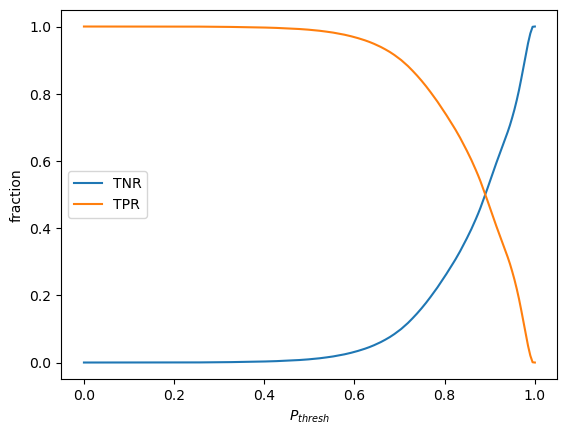

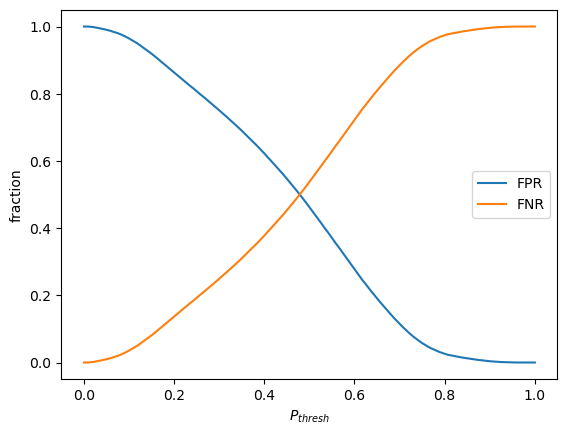

In [9]:
score_thresh = np.linspace(0, 1, 200)

tpr = [(prob_test_nu > score).sum() / len(prob_test_nu) for score in score_thresh]
fpr = [(prob_test_nubar > score).sum() / len(prob_test_nubar) for score in score_thresh]
tnr = [(prob_test_nu < score).sum() / len(prob_test_nu) for score in score_thresh]
fnr = [(prob_test_nubar < score).sum() / len(prob_test_nubar) for score in score_thresh]

plt.plot(score_thresh, tnr, label="TNR")
plt.plot(score_thresh, tpr, label="TPR")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("$P_{thresh}$")
plt.show()

plt.plot(score_thresh, fpr, label="FPR")
plt.plot(score_thresh, fnr, label="FNR")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("$P_{thresh}$")
plt.show()

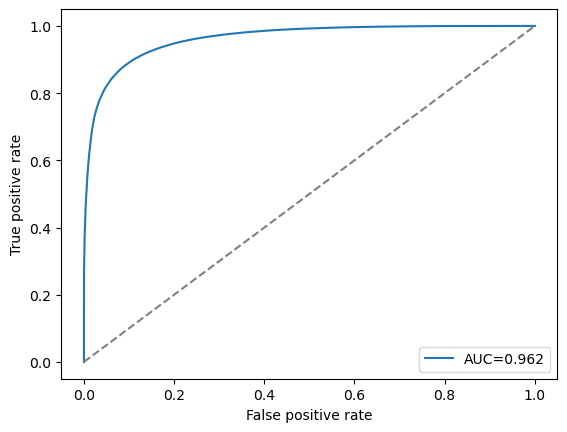

In [10]:
from scipy.integrate import trapezoid

auc = trapezoid(x=fpr[::-1], y=tpr[::-1])

# ROC
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

In [11]:
thresh = 0.85
tp_cm = (prob_test_nu > thresh).sum()
tn_cm = (prob_test_nubar < thresh).sum()
fn_cm = (prob_test_nu < thresh).sum()
fp_cm = (prob_test_nubar > thresh).sum()

print(f"""
|              | True | False |
| ------------ | ---- | ----- |
| **Positive** | {tp_cm} | {fp_cm} |
| **Negative** | {tn_cm} | {fn_cm} |
""")


|              | True | False |
| ------------ | ---- | ----- |
| **Positive** | 201577 | 1214 |
| **Negative** | 96859 | 119330 |



In [12]:
from sklearn.inspection import permutation_importance

r = permutation_importance(clf, X_data.to_pandas(), y_data)
for name, val in sorted(zip(X_data.columns, r["importances_mean"]), key=lambda x: x[1]):
    print(name, val)

recoE -0.0013488734823980497
mode -0.0007144745234997085
run 0.0
genie_weight 0.0
reco_pdg 0.0
direc_reco 0.0
Enu_e_had 0.0
Enu_mu_had 0.0
Enu_mu_range 0.0
n_reco_pfps 0.0
n_reco_tracks 0.0
n_reco_showers 0.0
single_hits_energy 0.0
n_reco_muons_pions 0.0
n_reco_protons 0.0
inelasticity 0.0
isCC 0.0003035949871025512
cvn_nue 0.0013614039358750718
cvn_nc 0.005392868501244363
cvn_numu 0.006761671371553568
NuMomY 0.008628708939643159
npfps 0.013616903462402918
direc_true 0.035528967126653634
weight 0.04894383194394467
osc_from_e_w 0.07461025814524222
osc_from_mu_w 0.07513224103580304
Ev 0.09765662619330193
flux_numu 0.15706911499793838
xsec 0.1704597542718404
flux_nue 0.3482522105808342
